In [1]:
import sys
import os
# dir = os.path.dirname(__file__)
# print('Get current working directory : ', dir + '/')
# sys.path.append(dir + '/')
import numpy as np
import random
import matplotlib.pyplot as plt
# import matplotlib as mpl
# plt.rcParams['text.usetex'] = True
from scipy.linalg import expm

plt.rcParams.update({
    # Matplotlib style for Nature journal figures.
# In general, they advocate for all fonts to be panel labels to be sans serif
# and all font sizes in a figure to be 7 pt and panel labels to be 8 pt bold.

# Figure size
    "figure.figsize": [3.3, 2.5],  # max width is 3.5 for single column

# Font sizes
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "font.size": 7,

# Font Family
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica", "Lucida Grande", "Verdana", "Geneva", "Lucid", "Avant Garde", "sans-serif"],
    # "font.sans-serif": ["Helvetica"],
    # "mathtext.fontset" : "dejavusans",

# Set line widths
    "axes.linewidth" : 0.5,
    "grid.linewidth" : 0.5,
    "lines.linewidth" : 1.0,
    "lines.markersize": 3,

# Always save as 'tight'
    "savefig.bbox" : "tight",
    "savefig.pad_inches" : 0.01})  # Use virtually all space when we specify figure dimensions


In [2]:
batchsize = 20
N = 10
with open("plot_data_snapshots=" + str(batchsize) +"_K="+str(N), "rb") as f:
    mean_vals = np.load(f)
    std_vals = np.load(f)
    mean_vals_k = np.load(f)
    std_vals_k = np.load(f)
    L_vals = np.load(f)
    t_vals = np.load(f)
    t_vals_k = np.load(f)
    t_vals_class = np.load(f)
    t_vals_class_k = np.load(f)

/home/asrivastava/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/asrivastava/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/home/asrivastava/anaconda3/lib/python3.12/site-packages/numpy/ma/core.py:3413: ComplexWarning: Casting complex values to real discards the imaginary part
  _data[indx] = dval


Snapshots = 20, batches = 10


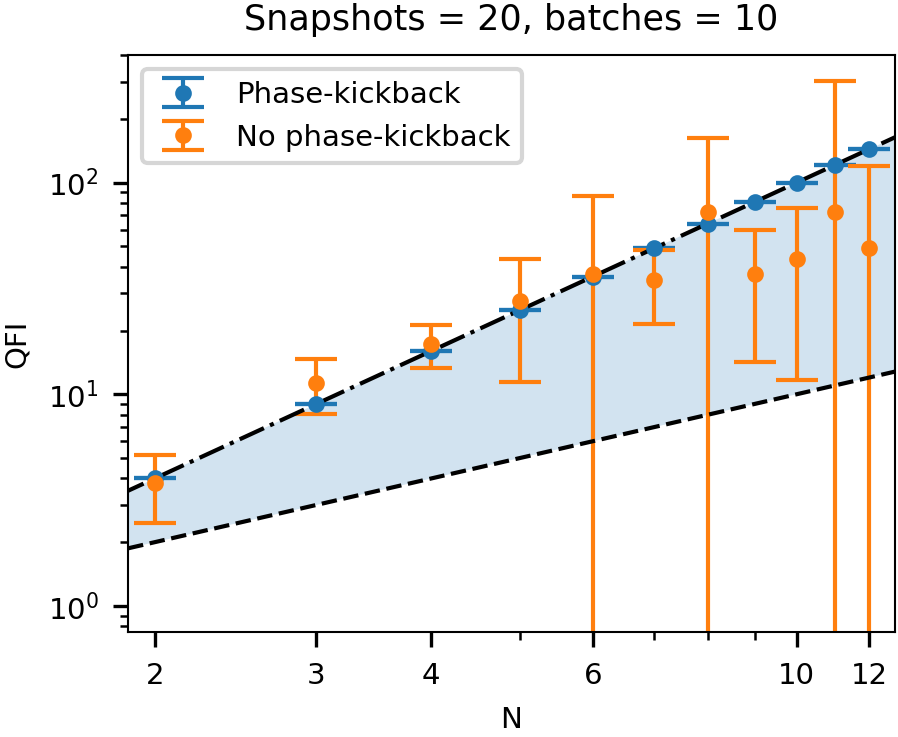

In [6]:
# mean_vals = np.median(medians)
# yerr = np.std(medians)

plt.figure(dpi = 300)
# L_square = [L_vals[i]**2 for i in range(len(L_vals))]

plt.errorbar(
    L_vals,
    mean_vals_k,
    yerr=std_vals_k,
    fmt='o',
    capsize=5,
    label=r"Phase-kickback"
)

plt.errorbar(
    L_vals,
    mean_vals,
    yerr=std_vals,
    fmt='o',
    capsize=5,
    label=r"No phase-kickback"
)
L_vals1 = np.arange(1, 15)
L_sq = [L_vals1[i]**2 for i in range(len(L_vals1))]

plt.xlabel("N")
plt.ylabel(r"QFI")
# plt.ylabel(r"Tr$[\rho L^2]$")
plt.plot(L_vals1, L_sq, '-.', color = 'black')#,label = r"$N^2$"
plt.plot(L_vals1, L_vals1, '--', color = 'black')#,label = r"$N$"
plt.fill_between(L_vals1, L_vals1, L_sq, alpha=0.2)
plt.yscale("log")
plt.xscale("log")
title_string = "Snapshots = "+str(batchsize)+", batches = "+str(N)
print(title_string)
plt.title(title_string)
plt.xlim(1.87, 12.8)
# plt.xticks(L_vals, [str(L_vals[i]) for i in range(len(L_vals))])
# plt.xticks([],[])
plt.xticks([2,3, 4,6,10, 12],['2','3', '4','6','10','12'])
plt.legend()
plt.savefig("Loglog_Ramsay_kickback_"+str(batchsize)+"_"+str(N)+".png", dpi = 300)
plt.show()

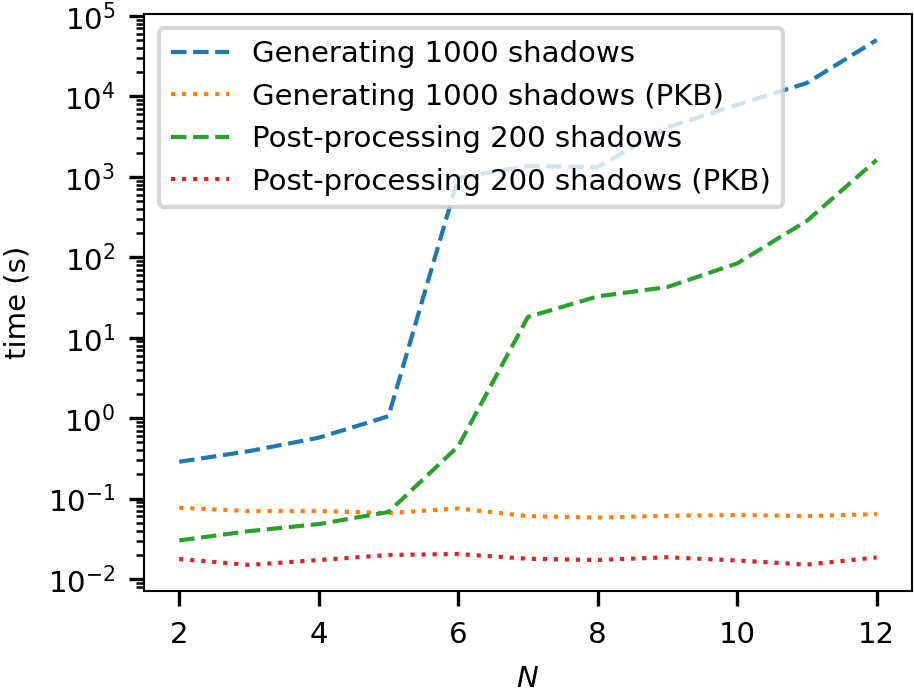

In [9]:
plt.figure(dpi = 300)
plt.yscale("log")
plt.plot(L_vals, t_vals, '--', label = "Generating 1000 shadows")
plt.plot(L_vals, t_vals_k, ':', label = "Generating 1000 shadows (PKB)")

plt.plot(L_vals, t_vals_class, '--', label = "Post-processing 200 shadows")
plt.plot(L_vals, t_vals_class_k, ':', label = "Post-processing 200 shadows (PKB)")

plt.ylabel("time (s)")
plt.xlabel(r"$N$")
plt.legend()
plt.savefig("Time_Ramsay_kickback_"+str(batchsize)+"_"+str(N)+".png", dpi = 300)
plt.show()